# Employee Attrition Analysis
**Exploring the relationship between salary band, overtime, and employee turnover**

---

## 1. Setup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_theme(style="whitegrid", context="notebook")

# Custom palette — blue for No, orange-red for Yes
palette = {
    "No":  "#378ADD",
    "Yes": "#D85A30"
}

## 2. Load Data

In [ ]:
df = pd.read_csv("../data/raw/employees.csv")
df.head()

## 3. Feature Engineering

- **Exited**: binary encoding of the `Attrition` column (`Yes → 1`, `No → 0`)  
- **SalaryBand**: three-tier bucketing of `MonthlyIncome`
  - **Low** — up to \$4,000  
  - **Medium** — \$4,001 – \$7,000  
  - **High** — above \$7,000

In [ ]:
df["Exited"] = df["Attrition"].map({"Yes": 1, "No": 0})

df["SalaryBand"] = pd.cut(
    df["MonthlyIncome"],
    bins=[0, 4000, 7000, float("inf")],
    labels=["Low", "Medium", "High"]
)

## 4. Aggregation

Average attrition rate (%) per `SalaryBand × OverTime` combination.

In [ ]:
plot_df = (
    df.groupby(["SalaryBand", "OverTime"], observed=True)["Exited"]
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={"Exited": "AttritionRate"})
)

plot_df

## 5. Visualization

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_df,
    x="SalaryBand",
    y="AttritionRate",
    hue="OverTime",
    palette=palette
)

plt.title("Attrition Rate by Salary Band and Overtime", fontsize=14, pad=12)
plt.xlabel("Salary Band")
plt.ylabel("Attrition Rate (%)")
plt.legend(title="OverTime")
plt.tight_layout()

plt.savefig("../images/attrition_salary_overtime.png", dpi=300, bbox_inches="tight")
plt.show()


Employees with lower salaries who work overtime show the highest attrition rates.

Overtime increases attrition across all salary bands, while higher salaries help reduce this effect.

In [ ]:
plot_overtime = (
    df.groupby("OverTime")["Exited"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
  )
print(plot_overtime)

In [ ]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=plot_overtime,
    x="OverTime",
    y="Exited",
    hue="OverTime",
    palette={"No": "#4C72B0", "Yes": "#DD8452"},
    legend=False,
    width=0.5
)

for i, v in enumerate(plot_overtime["Exited"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=11)

plt.title("Attrition Rate by Overtime", fontsize=14, pad=12)
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")
plt.ylim(0, 35)

plt.tight_layout()

plt.savefig("../images/plot_overtime.png", dpi=300, bbox_inches="tight")
plt.show()

Employees who work overtime show significantly higher attrition rates compared to those who do not.

In [ ]:
attrition_department = ( 
  df.groupby("Department")["Exited"] 
  .mean()
  .mul(100)
  .round(2)
  .reset_index() 
  ) 
print(attrition_department)

Employees in the Sales department show the highest attrition rate, which may reflect the high-pressure nature of sales roles.

Human Resources also presents a relatively high attrition rate, only slightly below Sales, suggesting that this department may require further investigation to better understand the drivers of employee turnover.

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=attrition_department,
    y="Department",
    x="Exited",
    hue="Department",
    palette="Blues_d",
    legend=False
)

for i, v in enumerate(attrition_department["Exited"]):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=10)

plt.title("Attrition Rate by Department", fontsize=13, pad=10)
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Department")

plt.xlim(0, 25)

plt.tight_layout()

plt.savefig("../images/attrition_department.png", dpi=300, bbox_inches="tight")
plt.show()

Sales shows the highest attrition rate. Human Resources also presents a relatively high level of turnover, while Research & Development, although lower, remains close to the other departments.

In [ ]:
attrition_jobsatisfaction = ( 
  df.groupby("JobSatisfaction")["Exited"] 
  .mean()
  .mul(100)
  .round(2)
  .reset_index() 
  ) 
print(attrition_jobsatisfaction)

Employees with lower levels of job satisfaction show higher attrition rates, while those with higher satisfaction tend to be more stable.

Mid-level satisfaction groups display similar behavior, suggesting that the most significant difference occurs between the lowest and highest levels.

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=attrition_jobsatisfaction,
    x="JobSatisfaction",
    y="Exited",
    hue="JobSatisfaction",
    palette="Blues_d",
    legend=False
)

for i, v in enumerate(attrition_jobsatisfaction["Exited"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)

plt.title("Attrition Rate by Job Satisfaction", fontsize=13, pad=10)
plt.xlabel("Job Satisfaction")
plt.ylabel("Attrition Rate (%)")
plt.ylim(0, 28)

plt.tight_layout()

plt.savefig("../images/attrition_job_satisfaction.png", dpi=300, bbox_inches="tight")
plt.show()

Employees with lower levels of job satisfaction show higher attrition rates, while those with higher satisfaction tend to be more stable.

Mid-level satisfaction groups display similar behavior, suggesting that the most significant difference occurs between the lowest and highest levels.

In [126]:
df["TenureGroup"] = pd.cut(
    df["YearsAtCompany"],
    bins=[0, 2, 7, float("inf")],
    labels=["Early", "Mid", "Senior"]
)
tenure_df = df.groupby("TenureGroup")["Exited"].mean().mul(100).round(2).reset_index()

Employees with shorter tenure show significantly higher attrition rates.

As time at the company increases, attrition rates decrease, indicating greater stability among more experienced employees.

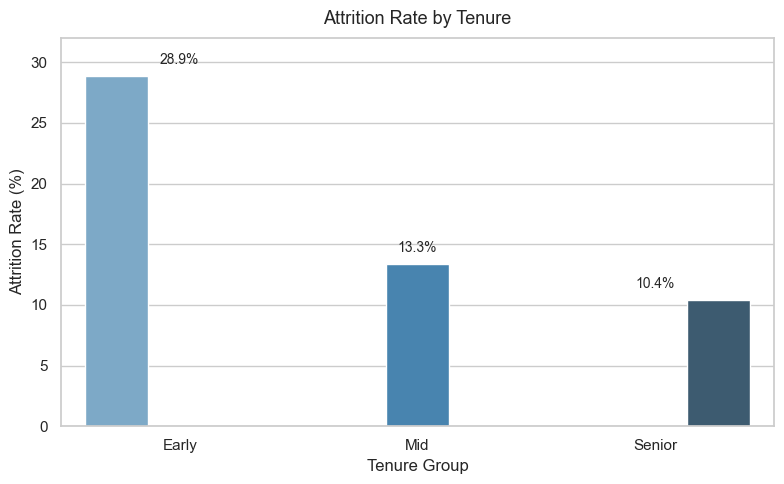

In [127]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=tenure_df,
    x="TenureGroup",
    y="Exited",
    hue="TenureGroup",
    palette="Blues_d",
    legend=False
)

for i, v in enumerate(tenure_df["Exited"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)

plt.title("Attrition Rate by Tenure", fontsize=13, pad=10)
plt.xlabel("Tenure Group")
plt.ylabel("Attrition Rate (%)")
plt.ylim(0, 32)

plt.tight_layout()

plt.savefig("../images/attrition_tenure.png", dpi=300, bbox_inches="tight")
plt.show()

Employees with shorter tenure show significantly higher attrition rates.

As time at the company increases, attrition rates decrease, indicating greater stability among more experienced employees.